In [1]:
import importlib
from pathlib import Path
import sys
import warnings
import arviz as az
import jax
import jax.numpy as jnp
import jax.random as random
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.control_flow import scan
from numpyro.infer import MCMC, NUTS
from numpyro.infer import Predictive
import numpy as np
import pandas as pd
warnings.simplefilter("ignore")
project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "src"))
from func_data_build import build_dataset
from func_hmc.hmc_priors import get_prior_family
from func_hmc.hmc_hsa import model_hsa_full, model_hsa_full_orth
import func_hmc.hmc_hsa as hmc_hsa_module
from func_hmc.hmc_utils import display_hmc_results, display_hmc_posterior_prior, display_hmc_convergence, save_idata_map
from func_hmc.hmc_sampling_params import hmc_sampling_params

data_dir = project_root / "data"
idat_dir = project_root / "results" / "idata"
tex_dir = project_root / "results" / "tex"
# Base figure output dir. Model/infl-specific subdirs are created below.
base_fig_dir = project_root / "results" / "fig"
prior_family = get_prior_family("hsa_full")
data = build_dataset(data_dir)
data = data.loc["1982-01-01":"2012-12-31"].copy()
data["DATE"] = pd.to_datetime(data.index)
# ==================================================================================================
# for reproducibility
chains = 2
sampling_params = hmc_sampling_params(chains=chains)
rng_key = jax.random.PRNGKey(0)
rng_keys = jax.random.split(rng_key, chains)
numpyro.enable_x64()


# for MCMC
# NOTE: run both PPI and CPI variants by switching these column mappings.
inflation_specs = {
    "ppi": {
        "pi": "pi_ppi",
        "pi_prev": "pi_ppi_prev",
        # SPF has GDP deflator and CPI expectations; for PPI we use GDP deflator by default.
        "pi_expect": "Epi_spf_gdp",
    },
    "cpi": {
        "pi": "pi_cpi",
        "pi_prev": "pi_cpi_prev",
        "pi_expect": "Epi_spf_cpi",
    },
}

x_datasets = {
    "unemp_gap": (
        jnp.array(data["unemp_gap"], dtype=jnp.float64),
        jnp.array(data["unemp_gap_prev"], dtype=jnp.float64),
    ),
    "output_gap_BN": (
        jnp.array(data["output_gap_BN"], dtype=jnp.float64),
        jnp.array(data["output_gap_BN_prev"], dtype=jnp.float64),
    ),
    "markup_BN_inv": (
        jnp.array(data["markup_BN_inv"], dtype=jnp.float64),
        jnp.array(data["markup_BN_inv_prev"], dtype=jnp.float64),
    ),
    "markup_inv": (
        jnp.array(data["markup_inv"], dtype=jnp.float64),
        jnp.array(data["markup_inv_prev"], dtype=jnp.float64),
    ),
}


/opt/homebrew/Caskroom/miniforge/base/envs/bayes-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Estimation

In [2]:
importlib.reload(hmc_hsa_module)
model_dict = {
    "HSA": lambda *args: model_hsa_full(*args),
    "HSA_orth": lambda *args: model_hsa_full_orth(*args),
}

dict_idata = {}
print("=== Run models ===")

for infl, spec in inflation_specs.items():
    pi = jnp.array(data[spec["pi"]], dtype=jnp.float64)
    pi_prev = jnp.array(data[spec["pi_prev"]], dtype=jnp.float64)
    pi_expect = jnp.array(data[spec["pi_expect"]], dtype=jnp.float64)
    N = jnp.array(data["N"], dtype=jnp.float64)
    print(f"--- Inflation: {infl} ---")

    for x_name, (x, x_prev) in x_datasets.items():
        for model_name, m in model_dict.items():
            run_name = f"{infl.upper()}_{model_name}_{x_name}"
            print(f"Running NKPC model: {run_name}")

            kernel = NUTS(m, target_accept_prob=sampling_params["target_accept"])
            mcmc = MCMC(
                kernel,
                num_warmup=sampling_params["warmup"],
                num_samples=sampling_params["samples"],
                num_chains=sampling_params["chains"],
                chain_method=sampling_params["chain_method"],
                progress_bar=sampling_params["progress_bar"],
            )

            mcmc.run(
                rng_keys,
                pi,
                pi_prev,
                pi_expect,
                x,
                x_prev,
                N,
                len(pi),
                prior_family,
            )

            idata = az.from_numpyro(mcmc)
            dict_idata[run_name] = idata

            diverging = idata.sample_stats["diverging"].values
            ratio_div = float(np.mean(diverging))
            print(f"Divergence ratio for {run_name}: {ratio_div:.4%}")

print("=== All models finished ===")


=== Run models ===
--- Inflation: ppi ---
Running NKPC model: PPI_HSA_unemp_gap


sample: 100%|██████████| 25000/25000 [29:43<00:00, 14.01it/s, 255 steps of size 2.48e-02. acc. prob=0.95] 


Divergence ratio for PPI_HSA_unemp_gap: 0.0000%
Running NKPC model: PPI_HSA_orth_unemp_gap


sample: 100%|██████████| 25000/25000 [26:08<00:00, 15.94it/s, 255 steps of size 2.46e-02. acc. prob=0.95] 


Divergence ratio for PPI_HSA_orth_unemp_gap: 0.0000%
Running NKPC model: PPI_HSA_output_gap_BN


...

Divergence ratio for CPI_HSA_orth_output_gap_BN: 0.0000%
Running NKPC model: CPI_HSA_markup_BN_inv


sample: 100%|██████████| 25000/25000 [26:52<00:00, 15.51it/s, 767 steps of size 2.63e-02. acc. prob=0.94] 


Divergence ratio for CPI_HSA_markup_BN_inv: 0.0000%
Running NKPC model: CPI_HSA_orth_markup_BN_inv


sample: 100%|██████████| 25000/25000 [24:15<00:00, 17.18it/s, 511 steps of size 2.37e-02. acc. prob=0.95] 


Divergence ratio for CPI_HSA_orth_markup_BN_inv: 0.0000%
=== All models finished ===


## Results

### HMC HSA Results (PPI)

model,alpha,delta,gamma,phi_1,rho_1,rho_2
PPI_HSA_markup_BN_inv,0.7870,-0.0550,-0.0270,0.6640,1.7860,-0.8850
PPI_HSA_orth_markup_BN_inv,0.7880,-0.0360,-0.0260,0.6670,1.7860,-0.8850
PPI_HSA_orth_output_gap_BN,0.7880,0.0160,0.0140,0.9060,1.7870,-0.8860
PPI_HSA_orth_unemp_gap,0.7770,0.0160,0.0050,0.9440,1.7860,-0.8850
PPI_HSA_output_gap_BN,0.8170,-0.0000,-0.0180,0.9030,1.7870,-0.8860
PPI_HSA_unemp_gap,0.7810,0.0070,0.0090,0.9440,1.7860,-0.8850


model,SDDR_BF01_alpha,SDDR_BF01_delta,SDDR_BF01_gamma,SDDR_BF01_phi_1,SDDR_BF01_rho_1,SDDR_BF01_rho_2
PPI_HSA_unemp_gap,0.0000,6.6125,1.9839,0.0000,,
PPI_HSA_output_gap_BN,0.0000,6.7194,1.9483,0.0000,,
PPI_HSA_markup_BN_inv,0.0000,2.3777,1.9004,0.0000,,
PPI_HSA_orth_unemp_gap,0.0000,6.1285,1.9822,0.0000,,
PPI_HSA_orth_output_gap_BN,0.0000,6.0688,1.9669,0.0000,,
PPI_HSA_orth_markup_BN_inv,0.0000,3.3242,1.8812,0.0000,,


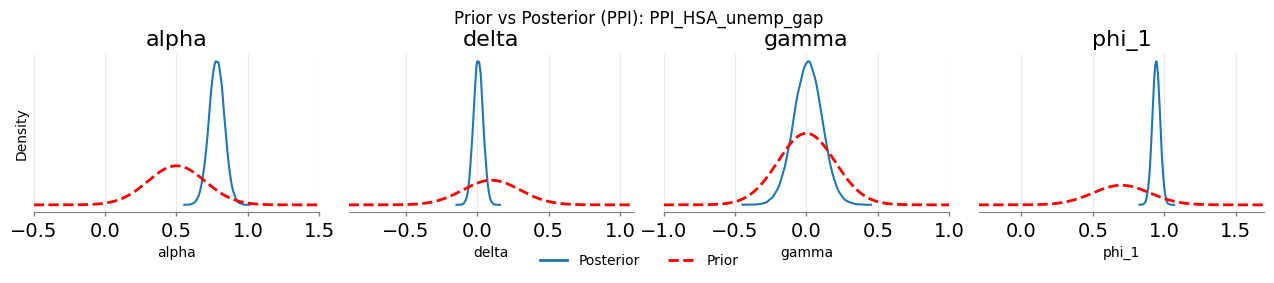

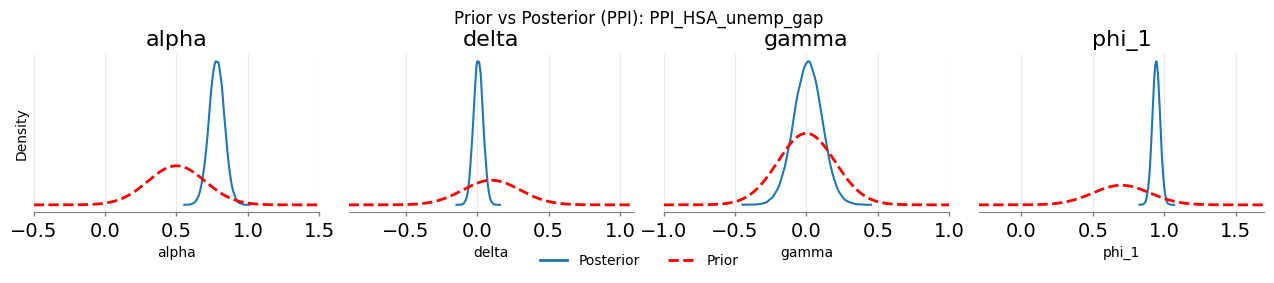

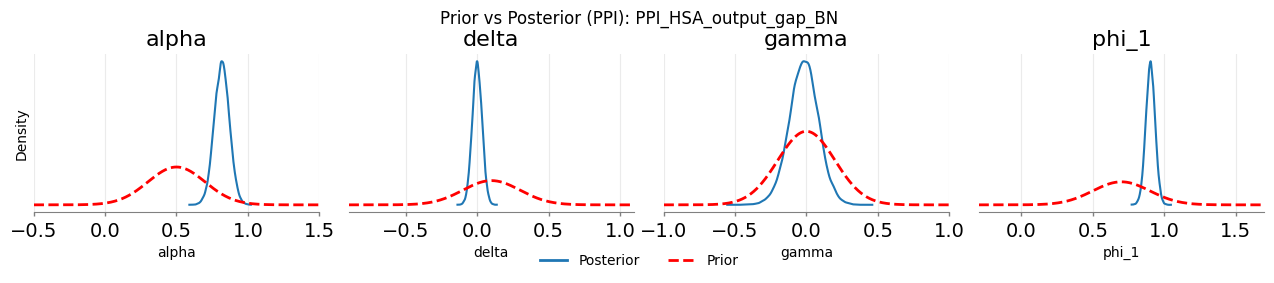

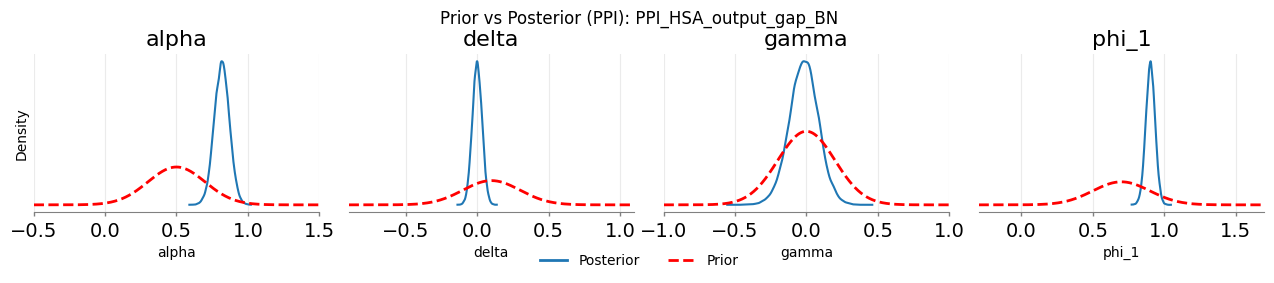

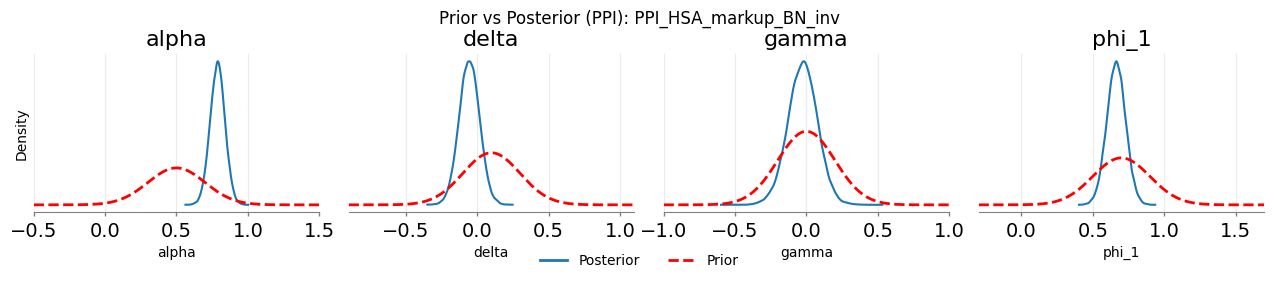

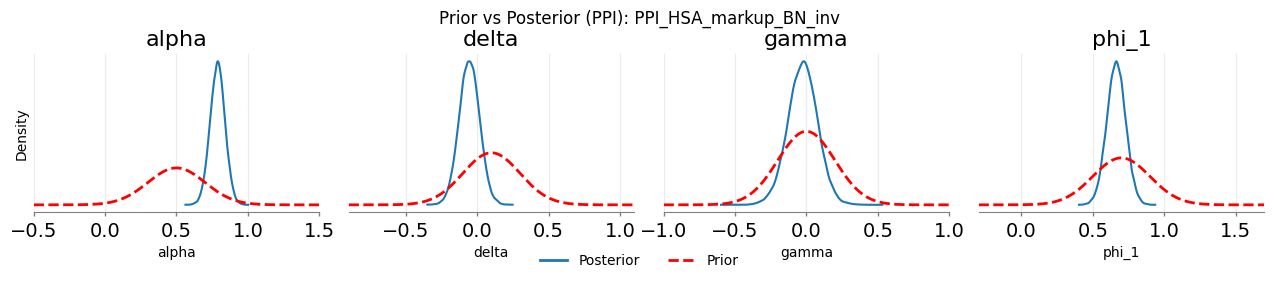

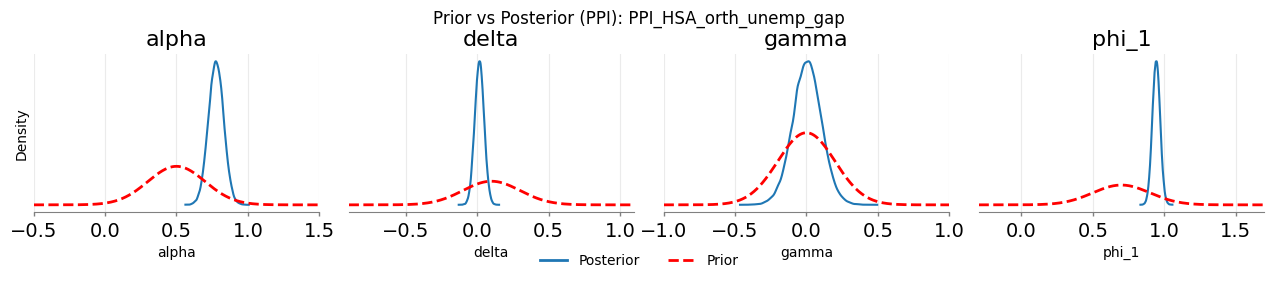

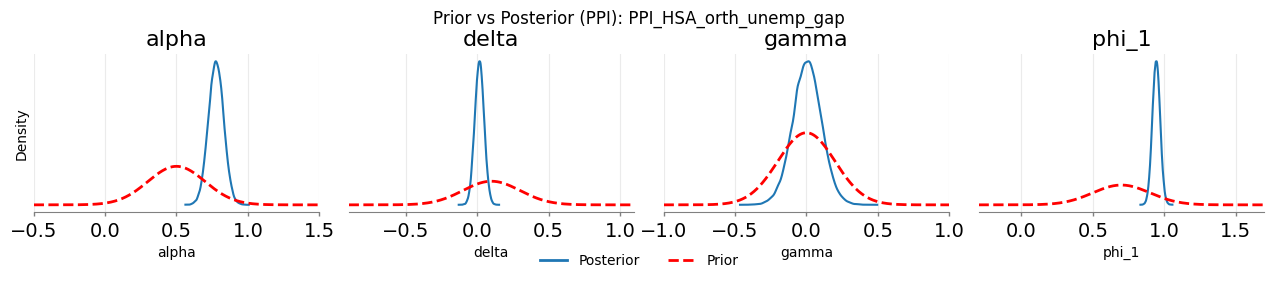

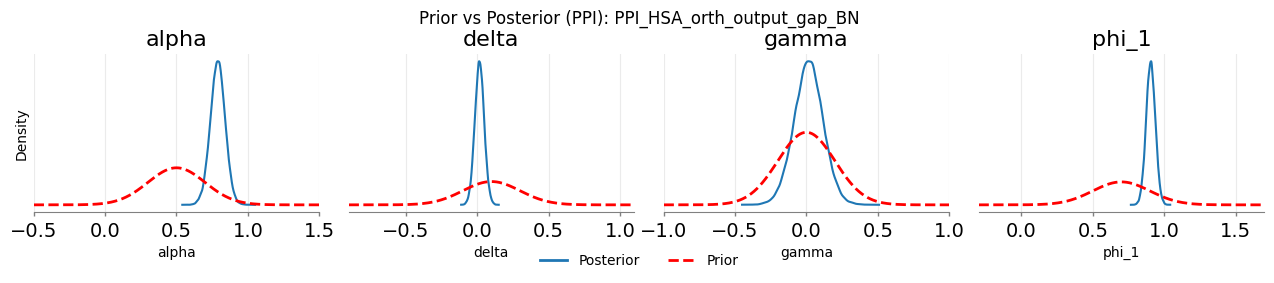

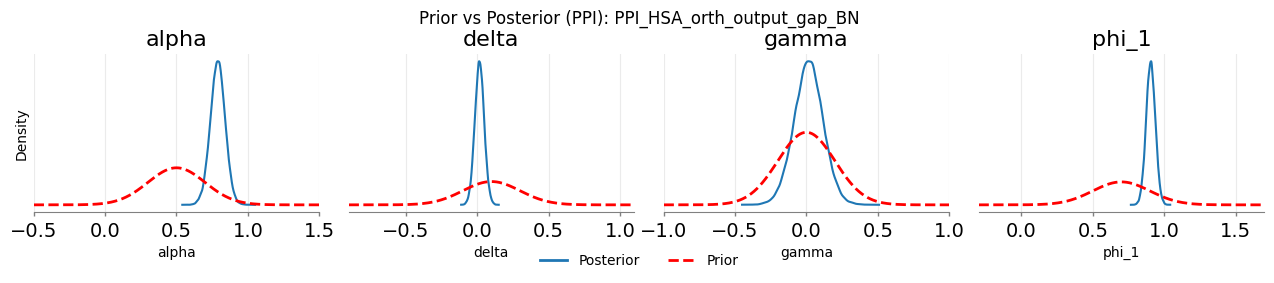

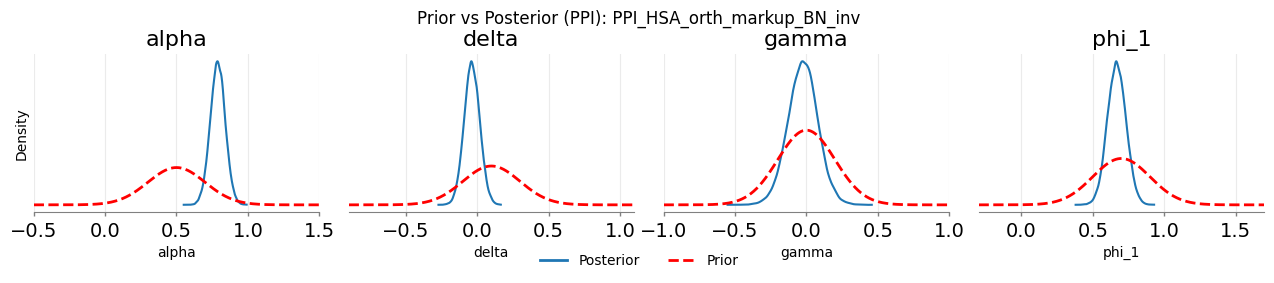

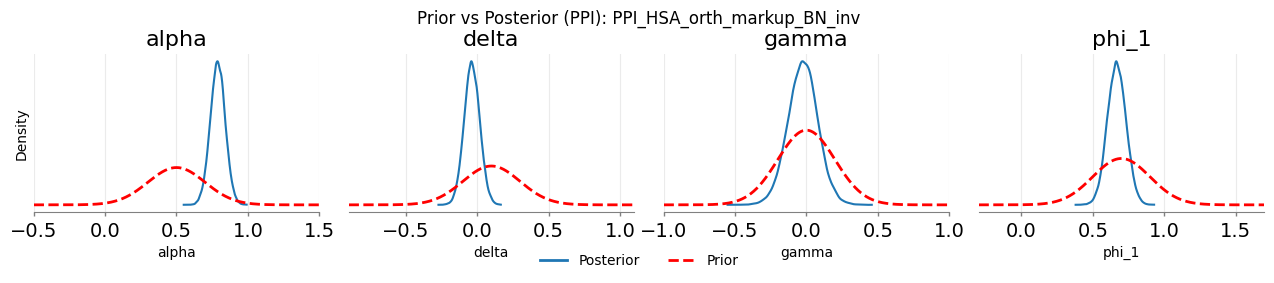

### HMC HSA Results (CPI)

model,alpha,delta,gamma,phi_1,rho_1,rho_2
CPI_HSA_markup_BN_inv,0.6560,-0.0070,0.0150,0.6620,1.7860,-0.8850
CPI_HSA_orth_markup_BN_inv,0.6560,-0.0040,0.0150,0.6670,1.7860,-0.8840
CPI_HSA_orth_output_gap_BN,0.6770,-0.0300,0.0160,0.9060,1.7850,-0.8840
CPI_HSA_orth_unemp_gap,0.6300,0.0340,0.0250,0.9440,1.7860,-0.8850
CPI_HSA_output_gap_BN,0.6660,-0.0300,0.0200,0.9050,1.7850,-0.8840
CPI_HSA_unemp_gap,0.6320,0.0340,0.0250,0.9430,1.7860,-0.8850


model,SDDR_BF01_alpha,SDDR_BF01_delta,SDDR_BF01_gamma,SDDR_BF01_phi_1,SDDR_BF01_rho_1,SDDR_BF01_rho_2
CPI_HSA_unemp_gap,0.0000,2.9286,4.4634,0.0000,,
CPI_HSA_output_gap_BN,0.0000,4.1400,4.5781,0.0000,,
CPI_HSA_markup_BN_inv,0.0000,7.3137,4.7019,0.0000,,
CPI_HSA_orth_unemp_gap,0.0000,2.8931,4.4355,0.0000,,
CPI_HSA_orth_output_gap_BN,0.0000,4.2050,4.8273,0.0000,,
CPI_HSA_orth_markup_BN_inv,0.0000,8.0189,4.6850,0.0000,,


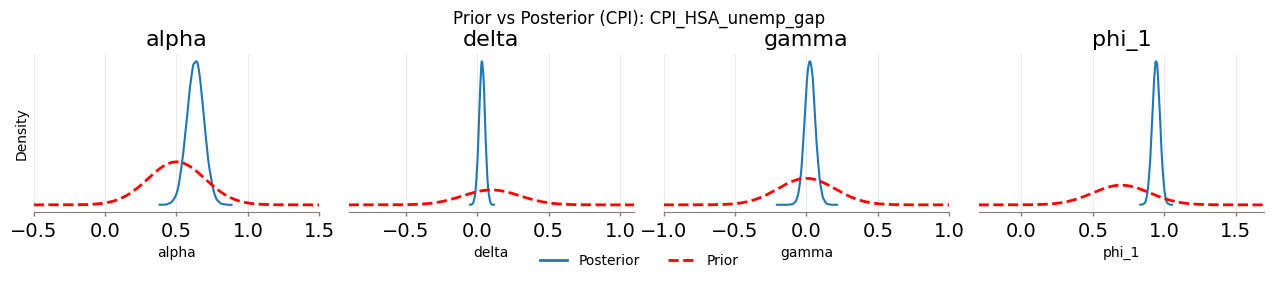

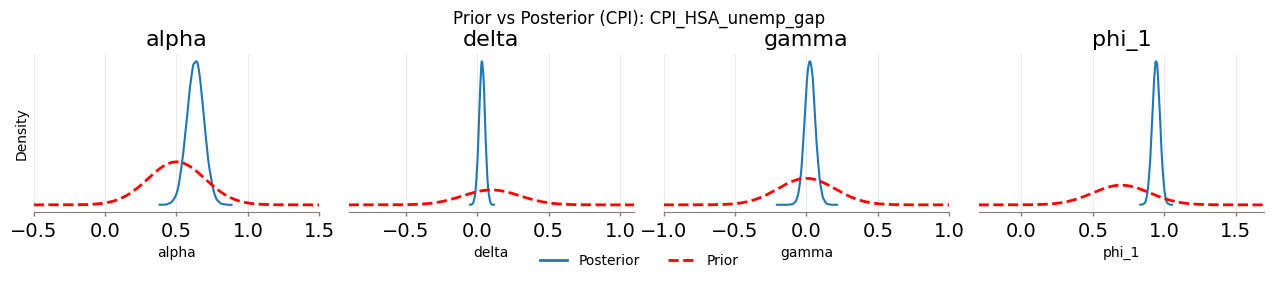

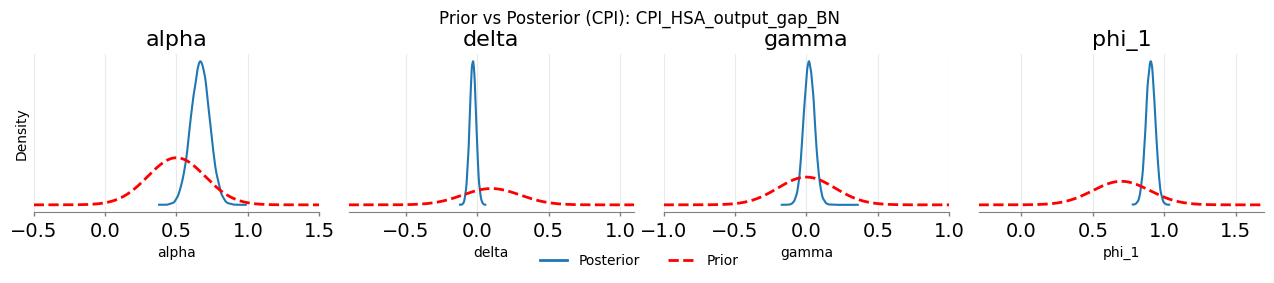

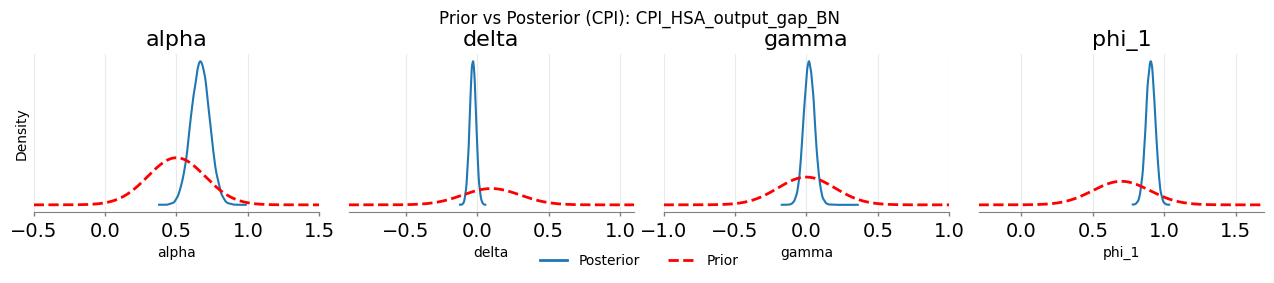

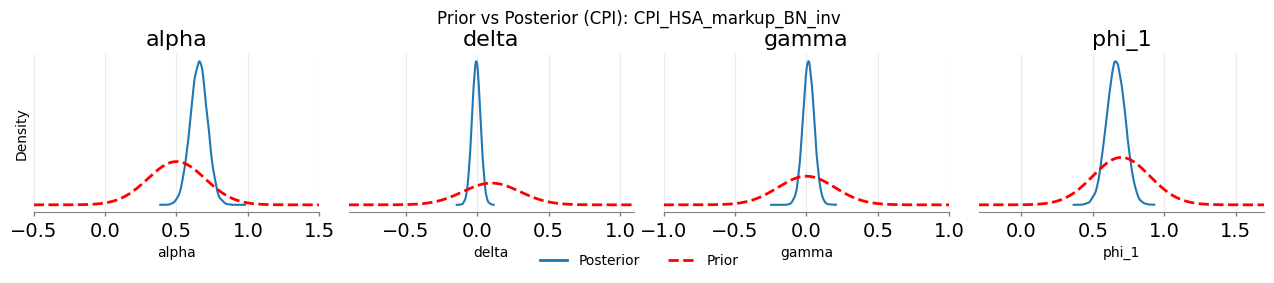

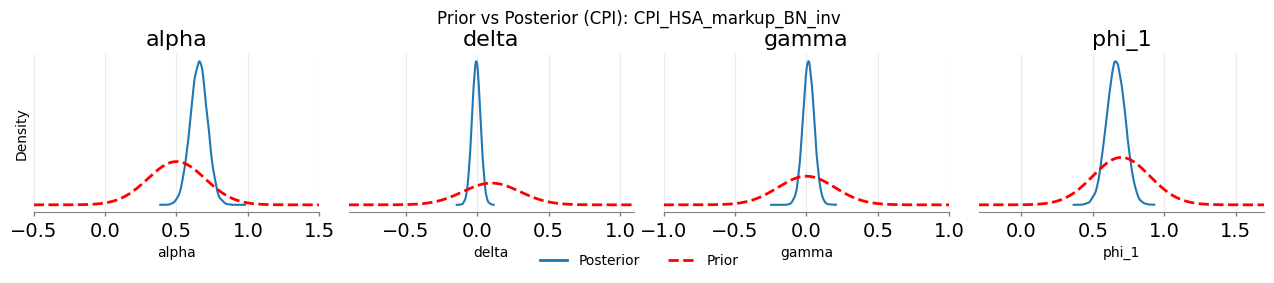

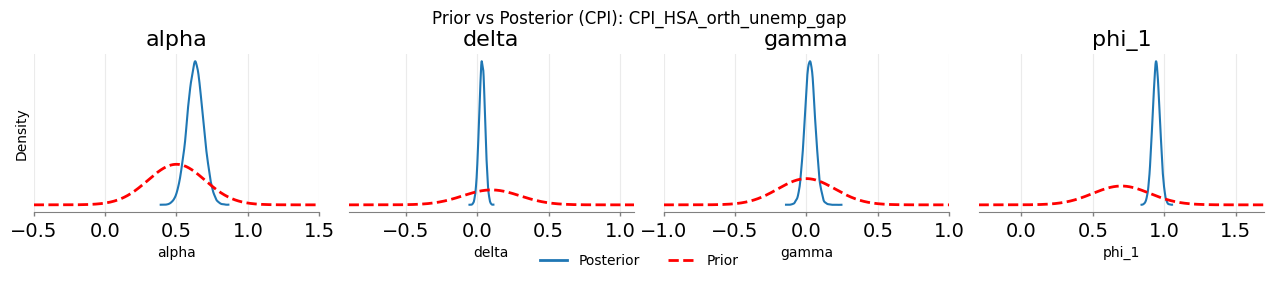

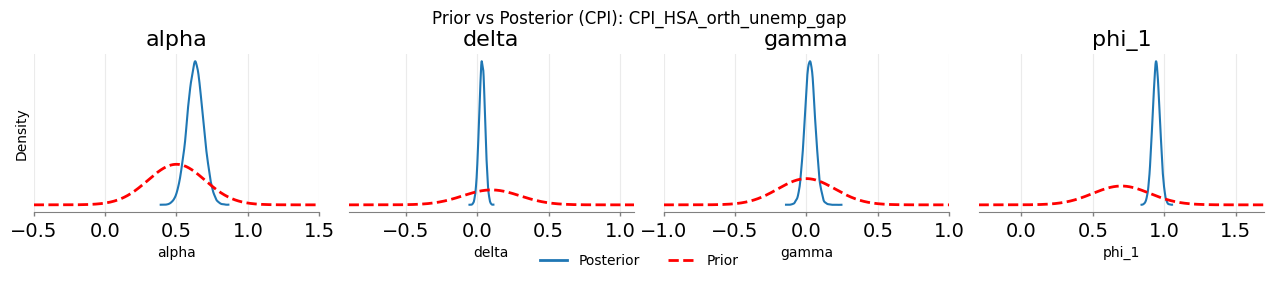

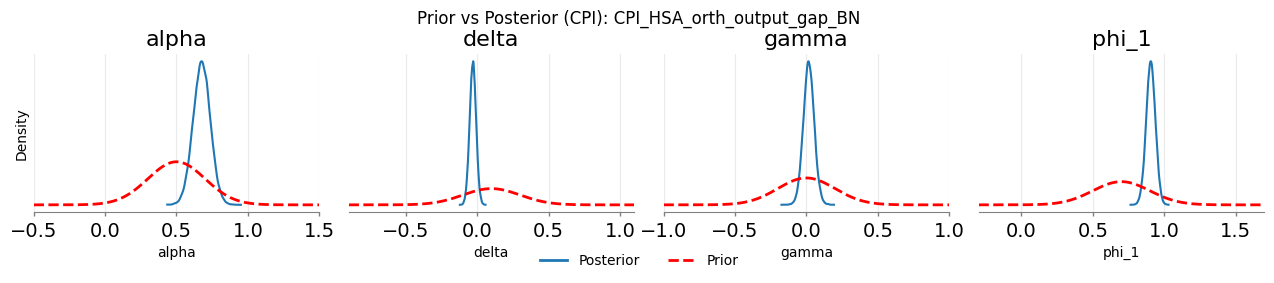

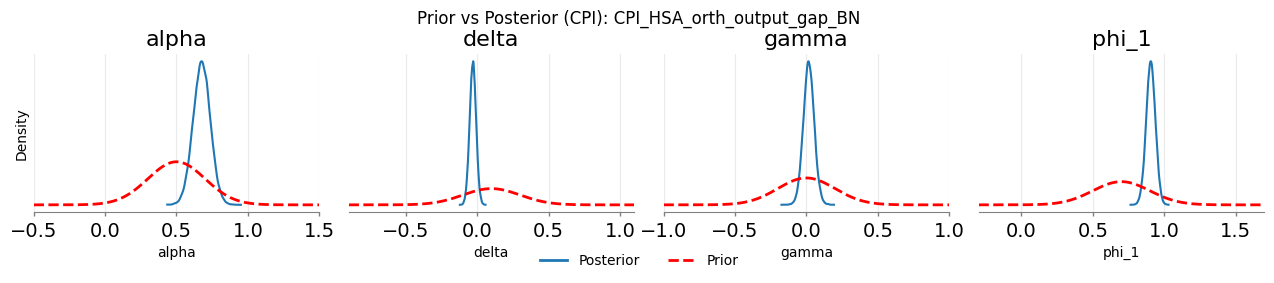

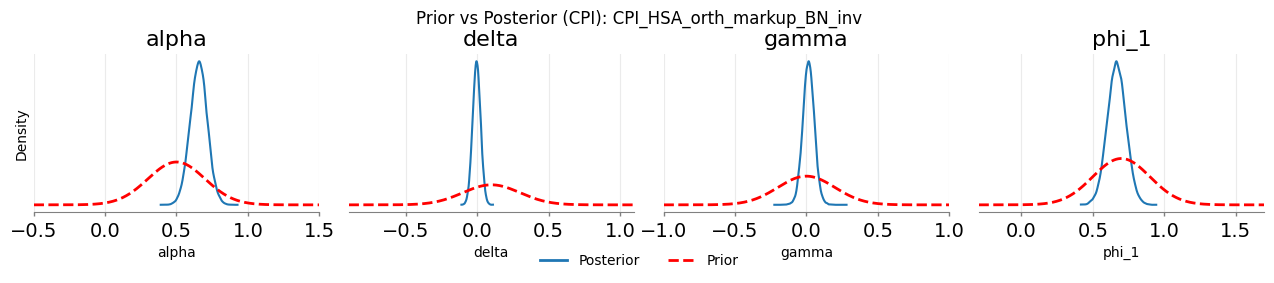

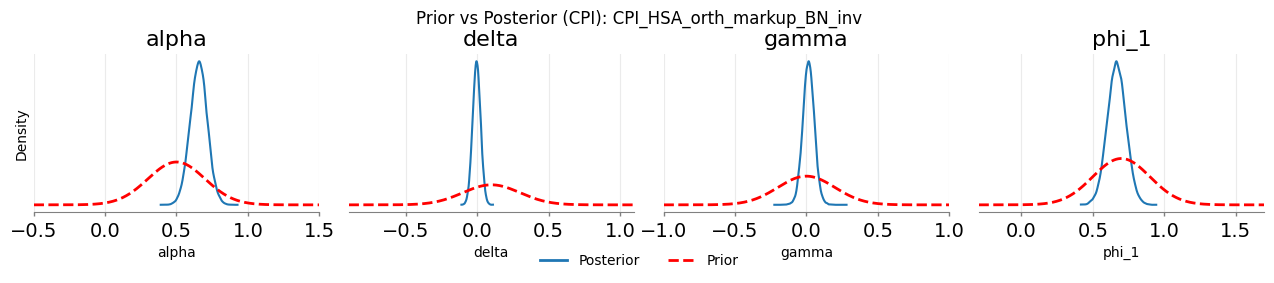

In [3]:
hmc_prior_specs = get_prior_family("hsa_full").specs
base_models_to_show = [
    "HSA_unemp_gap",
    "HSA_output_gap_BN",
    "HSA_markup_BN_inv",
    "HSA_markup_inv",
    "HSA_orth_unemp_gap",
    "HSA_orth_output_gap_BN",
    "HSA_orth_markup_BN_inv",
    "HSA_orth_markup_inv",
]

for infl in inflation_specs.keys():
    models_to_show = [f"{infl.upper()}_{m}" for m in base_models_to_show]
    dict_items_fill = {k: dict_idata[k] for k in models_to_show if k in dict_idata}

    display_hmc_results(
        dict_items_fill,
        hmc_prior_specs,
        models_to_show=models_to_show,
        tex_dir=tex_dir,
        params=("alpha", "delta", "gamma", "phi_1", "rho_1", "rho_2"),
        title=f"HMC HSA Results ({infl.upper()})",
    )

    # Put figures under results/fig/hmc_hsa_full/<infl>/...
    fig_dir = base_fig_dir / "hmc_hsa_full" / infl.lower()
    fig_dir.mkdir(parents=True, exist_ok=True)

    display_hmc_posterior_prior(
        dict_items_fill,
        hmc_prior_specs,
        models_to_show=models_to_show,
        fig_dir=fig_dir,
        params=("alpha", "delta", "gamma", "phi_1"),
        title=f"Prior vs Posterior ({infl.upper()})",
    )

    idata_dir = idat_dir / f"hmc_hsa_full_{infl.lower()}"
    save_idata_map(dict_items_fill, idata_dir)


In [4]:
# for infl in inflation_specs.keys():
#     models_to_show = [
#         f"{infl.upper()}_HSA_unemp_gap",
#         f"{infl.upper()}_HSA_output_gap_BN",
#         f"{infl.upper()}_HSA_markup_BN_inv",
#         f"{infl.upper()}_HSA_orth_unemp_gap",
#         f"{infl.upper()}_HSA_orth_output_gap_BN",
#         f"{infl.upper()}_HSA_orth_markup_BN_inv",
#     ]
#     dict_items_fill = {k: dict_idata[k] for k in models_to_show if k in dict_idata}

#     display_hmc_convergence(
#         dict_items_fill,
#         models_to_show=models_to_show,
#         fig_dir=fig_dir,
#         params=("alpha", "kappa", "theta", "phi_1", "rho_1", "rho_2", "sigma_e", "sigma_zeta"),
#         title=f"Convergence ({infl.upper()})",
#     )
